# Customer Churn Analysis and Prediction
This project aims to analyse customer churn in a telecommunications company and develop predictive models to identify at-risk customers. The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve customer retention.

## Task 1: Data Preparation
Loading and preprocess the dataset, addressing missing values, and encoding categorical variables for machine learning readiness

In [1]:
# Importing the required libraries

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report

import joblib

In [2]:
# Loading the dataset
df = pd.read_csv("dataset/Telco_Customer_Churn_Dataset.csv")

In [3]:
# Reading the top 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Showing the dataset structure, column data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Checking descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [6]:
# Checking descriptive statistics for all columns in the dataset
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Checking for missing values in each column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Checking duplicate records in the dataset
df.duplicated().sum()

np.int64(0)

In [9]:
df["SeniorCitizen"].unique()

array([0, 1])

In [10]:
df["StreamingMovies"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [11]:
df["tenure"].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [12]:
# Standardising categorical values in selected service-related columns
cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df[cols] = df[cols].replace(r"^No\s.*", "No", regex = True)

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [15]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
# Calculating the average tenure for each churn category
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [18]:
# Calculating the average monthly charges for each churn category
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [19]:
# Calculating the average monthly charges grouped by churn status and gender
df.groupby(["Churn", "gender"])["MonthlyCharges"].mean()

Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

In [20]:
# Counting the number of senior citizens and non-senior citizens within each churn category
df.groupby("Churn")["SeniorCitizen"].value_counts()

Churn  SeniorCitizen
No     0                4508
       1                 666
Yes    0                1393
       1                 476
Name: count, dtype: int64

In [21]:
# Calculating the number of contract types for each churn category
df.groupby("Churn")["Contract"].value_counts()

Churn  Contract      
No     Month-to-month    2220
       Two year          1647
       One year          1307
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

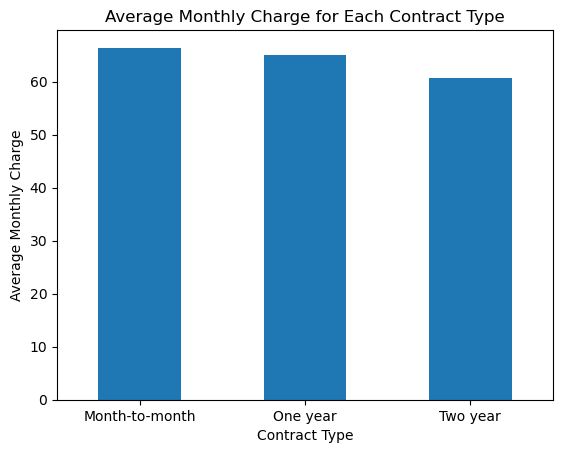

In [22]:
# Plotting the average monthly charge for each contract type using a bar chart
df.groupby("Contract")["MonthlyCharges"].mean().plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charge")
plt.title("Average Monthly Charge for Each Contract Type")
plt.xticks(rotation=0)
plt.show()

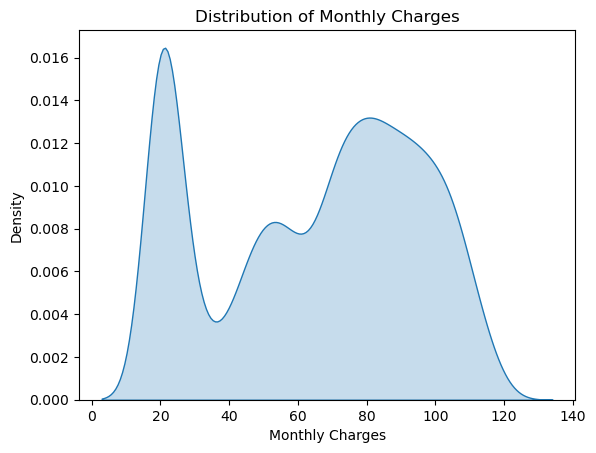

In [23]:
# Distribution of monthly charges
sns.kdeplot(df["MonthlyCharges"], fill=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

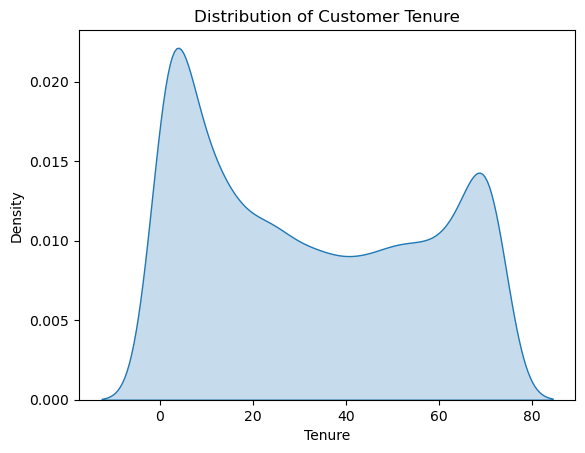

In [24]:
# Distribution of Tenure
sns.kdeplot(df["tenure"], fill=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.show()

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Tasks 2: Feature Selection
Selecting relevant features influencing churn prediction

In [26]:
# Defining the list of feature variables that will be used to train the machine learning model.
features = [
    "tenure",
    "MonthlyCharges",
    "SeniorCitizen",
    "Contract",
]

In [27]:
# Creating a copy of the selected feature columns for model training
X = df[features].copy()

In [28]:
X

,tenure,MonthlyCharges,SeniorCitizen,Contract
0,1,29.85,0,Month-to-month
1,34,56.95,0,One year
2,2,53.85,0,Month-to-month
3,45,42.30,0,One year
4,2,70.70,0,Month-to-month
...,...,...,...,...
7038,24,84.80,0,One year
7039,72,103.20,0,One year
7040,11,29.60,0,Month-to-month
7041,4,74.40,1,Month-to-month


In [29]:
# Defining Churn as the target variable the model will learn to predict.
target = "Churn"

In [30]:
# Extracting the target variable to represent the value to be predicted.
y = df[target]

In [31]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [32]:
label_encoders = {}
# Identify categorical column in the dataset.
categorical_columns = X.select_dtypes(include ="object").columns

In [33]:
categorical_columns

Index(['Contract'], dtype='object')

In [34]:
# Looping through each categorical column and applying label encoding.
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [35]:
label_encoders

{'Contract': LabelEncoder()}

In [36]:
X

,tenure,MonthlyCharges,SeniorCitizen,Contract
0,1,29.85,0,0
1,34,56.95,0,1
2,2,53.85,0,0
3,45,42.30,0,1
4,2,70.70,0,0
...,...,...,...,...
7038,24,84.80,0,1
7039,72,103.20,0,1
7040,11,29.60,0,0
7041,4,74.40,1,0


In [37]:
# Checking the data type of the 'Contract' column
type(X["Contract"][0])

numpy.int64

In [38]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [39]:
# Converting churn values to binary format: Yes = 1, No = 0
y.apply(lambda x: 1 if x == "Yes" else 0 )

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [40]:
# Assigning the binary format to 'y'
y = y.apply(lambda x: 1 if x == "Yes" else 0 )

In [41]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

# Tasks 3: Train-Test Split and Feature Scaling
Dividing the data into training (80%) and testing (20%) sets for model training and evaluation. Also, performing feature scaling

In [42]:
# Splitting the dataset into training and testing sets. 80% used for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [43]:
# Initialising the StandardScaler
scaler = StandardScaler()

In [44]:
# Fitting the scaler on the training data and transforming the features to a standardized scale
X_train = scaler.fit_transform(X_train)

In [45]:
# Saving the trained scaler for future use or deployment
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [46]:
# Transforming the test data using the scaler fitted on the training data
X_test = scaler.transform(X_test)

In [47]:
X_train

array([[-0.58946112, -0.49713959,  2.28742232, -0.83385949],
       [-1.28132415,  0.32880891, -0.43717332, -0.83385949],
       [ 0.34658886, -1.48927491, -0.43717332,  1.56306111],
       ...,
       [-0.54876329,  0.83567872, -0.43717332, -0.83385949],
       [ 1.44543015,  0.83567872, -0.43717332,  1.56306111],
       [-0.91504372,  0.706053  , -0.43717332, -0.83385949]],
      shape=(5634, 4))

In [48]:
X_test

array([[-0.79295024,  0.49831947, -0.43717332, -0.83385949],
       [ 0.67217147,  0.64954948, -0.43717332,  0.36460081],
       [ 0.99775407,  1.18965665,  2.28742232, -0.83385949],
       ...,
       [-0.83364807,  1.17469983, -0.43717332, -0.83385949],
       [-0.79295024,  1.1082251 , -0.43717332, -0.83385949],
       [ 0.95705624, -0.17639902, -0.43717332,  1.56306111]],
      shape=(1409, 4))

# Tasks 4 -6: Model Selection, Training and Evaluation
Choosing a suitable binary classification algorithm

In [49]:
# Defining a function to calculate and display model's accuracy score
def test_accuracy(predictions):
    print("Accuracy score of model is {}".format(accuracy_score(y_test, predictions)))

In [50]:
log_reg = LogisticRegression()

In [51]:
import warnings
warnings.filterwarnings("ignore")

In [52]:
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
X

,tenure,MonthlyCharges,SeniorCitizen,Contract
0,1,29.85,0,0
1,34,56.95,0,1
2,2,53.85,0,0
3,45,42.30,0,1
4,2,70.70,0,0
...,...,...,...,...
7038,24,84.80,0,1
7039,72,103.20,0,1
7040,11,29.60,0,0
7041,4,74.40,1,0


In [54]:
log_reg.predict([[30, 20, 0, 1]])[0]

np.int64(0)

In [55]:
y_pred = log_reg.predict(X_test)

In [56]:
test_accuracy(y_pred)
print("\nClassification Report: \n", classification_report(y_test, y_pred))


Accuracy score of model is 0.7977288857345636

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.88      0.87      1049
           1       0.62      0.55      0.58       360

    accuracy                           0.80      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [57]:
param_grid = {
    "criterion": ["ginni", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5]
}

In [58]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)

In [59]:
grid_tree.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['ginni', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [60]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'splitter': 'random'}

In [61]:
y_pred = grid_tree.predict(X_test)

In [62]:
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(1409,))

In [63]:
test_accuracy(y_pred)
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Accuracy score of model is 0.7743080198722498

Classification Report: 
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      1049
           1       0.56      0.54      0.55       360

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



In [64]:
rfc_model = RandomForestClassifier()

In [65]:
param_grid = {
    "n_estimators":[75, 100, 125],
    "max_features": ['sqrt', 'log2', None],
    "bootstrap": [True, False]
}

In [66]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)

In [67]:
grid_rfc.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [75, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [68]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 'log2', 'n_estimators': 100}

In [69]:
grid_rfc.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(1409,))

In [70]:
y_pred = grid_rfc.predict(X_test)

In [71]:
test_accuracy(y_pred)
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Accuracy score of model is 0.7565649396735273

Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.85      0.84      1049
           1       0.52      0.50      0.51       360

    accuracy                           0.76      1409
   macro avg       0.68      0.67      0.67      1409
weighted avg       0.75      0.76      0.75      1409



In [72]:
xgb_model=XGBClassifier()

In [73]:
param_grid={
    "n_estimators" : [75, 100, 200],
    "max_depth" : [3,5,7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}

In [74]:
grid_xgb=GridSearchCV(xgb_model, param_grid, cv=5)

In [75]:
grid_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 1], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [75, 100, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [76]:
grid_xgb.best_params_

{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 75,
 'subsample': 0.7}

In [77]:
grid_xgb.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(1409,))

In [78]:
y_pred = grid_xgb.predict(X_test)

In [79]:
test_accuracy(y_pred)
print("\nClassification Report: \n", classification_report(y_test, y_pred))

Accuracy score of model is 0.8055358410220014

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1049
           1       0.65      0.52      0.58       360

    accuracy                           0.81      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



Using Feature Importance of XGB model

In [80]:
best_grid_xgb = grid_xgb.best_estimator_

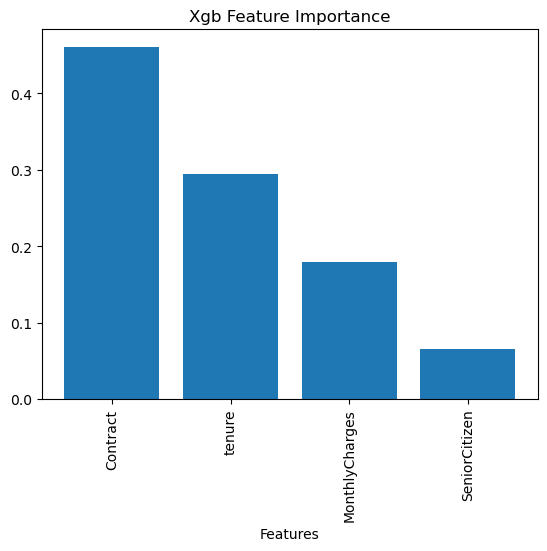

In [81]:
# Using feature importance scores from the trained XGBoost model to identify which features contribute the most to predictions.

# Create a dataframe for feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_grid_xgb.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=90)
plt.title("Xgb Feature Importance")
plt.xlabel("Features")
plt.show()

In [82]:
# Saving the label encoders to a file using pickle.
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [83]:
# Saving the trained XGBoost model to a file.
joblib.dump(best_grid_xgb, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']